# 11 — EDA fase 2: variable objetivo (`casos_Dengue`)

**Pregunta guía:** ¿qué es exactamente lo que queremos predecir y qué tan difícil es?

Dataset: `data/silver/integrado/meteo_socio_epi_piura_2017_2025.csv` (solo lectura). Tasas, episodios y marcas de brote se calculan **en memoria** para describir el objetivo; nada se guarda en `data/` ni es una feature.

**Supuestos de trabajo mientras Rosa decide (vienen de la fase 1):**
- 2025 se incluye, pero se marca aparte (otra fuente, posible subregistro), y las cifras clave se dan con y sin 2025.
- Las tasas usan la `poblacion` del dataset, con una sensibilidad para 2017 (ver fase 1, hallazgo 4).
- Lagunas, Montero y Sicchez se mantienen: sus ceros son ausencia en la fuente.

Etiquetas: **Observación** · **Hipótesis** · **Implicación**.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr

from src.utils.paths import SILVER
from src.eda.carga import cargar_integrado, OBJETIVO
from src.eda.objetivo import (
    tasa_100k, curva_concentracion, unidades_para_fraccion, rachas, resumen_definicion,
    brote_umbral_tasa, brote_percentil_distrito, brote_canal_endemico, brote_aumento_sostenido, umbral_canal_endemico,
)
from src.eda.estilo import aplicar_estilo, guardar_figura, guardar_metricas, COLORES

aplicar_estilo()
miles = lambda x: f"{x:,}".replace(",", " ")  # separador de miles en español
FASE = "fase2_variable_objetivo"
M = {}

df = cargar_integrado()
casos = df[OBJETIVO]
tasa = tasa_100k(casos, df["poblacion"])          # en memoria, solo para analizar
sin_2025 = df["anio"] < 2025
nombre = df.drop_duplicates("ubigeo").set_index("ubigeo")[["provincia", "distrito"]]
# Etiqueta legible: quita el sufijo artificial "_s" y agrega la provincia a los nombres repetidos (hay dos Salitral)
limpio = nombre["distrito"].str.replace(r"_s$", "", regex=True)
nombre["distrito"] = limpio.where(~limpio.duplicated(keep=False), limpio + " (" + nombre["provincia"] + ")")
print(df.shape)

(30485, 35)


## 1. Distribución: ceros, cola y sobredispersión

**Qué quiero saber:** qué tan inflado de ceros y qué tan sobredisperso es el conteo semanal, en total, por año y dentro de cada distrito-año. Esto determina qué familia de modelos o transformaciones tiene sentido.
**Qué espero:** ~78 % de ceros y varianza ≫ media (diccionario de datos).

In [2]:
def vm(s):
    return float(s.var() / s.mean()) if s.mean() > 0 else np.nan

M.update({
    "pct_ceros": round(float((casos == 0).mean() * 100), 2),
    "pct_ceros_sin_2025": round(float((casos[sin_2025] == 0).mean() * 100), 2),
    "media": round(float(casos.mean()), 2), "mediana": float(casos.median()), "maximo": int(casos.max()),
    "varianza_sobre_media": round(vm(casos), 1), "varianza_sobre_media_sin_2025": round(vm(casos[sin_2025]), 1),
    "p90_p99_casos_positivos": [float(casos[casos > 0].quantile(q)) for q in (0.9, 0.99)],
    "mediana_casos_positivos": float(casos[casos > 0].median()),
})
por_anio = df.groupby("anio")[OBJETIVO].agg(
    pct_ceros=lambda s: round((s == 0).mean() * 100, 1), casos="sum", maximo="max",
    var_sobre_media=lambda s: round(vm(s), 1))
por_anio["pct_casos_del_total"] = (por_anio["casos"] / por_anio["casos"].sum() * 100).round(1)
M["por_anio"] = {int(a): {k: (float(v) if not pd.isna(v) else None) for k, v in fila.items()} for a, fila in por_anio.iterrows()}

# Dentro de cada distrito-año (quita la heterogeneidad entre distritos y años)
da = df.groupby(["ubigeo", "anio"])[OBJETIVO].agg(["mean", "var"])
da = da[da["mean"] > 0]
M["distrito_anios_con_casos"] = int(len(da))
M["vm_mediana_distrito_anio"] = round(float((da["var"] / da["mean"]).median()), 2)
M["pct_distrito_anios_sobredispersos"] = round(float((da["var"] > da["mean"]).mean() * 100), 1)
M["pct_distrito_anios_vm_mayor_10"] = round(float((da["var"] / da["mean"] > 10).mean() * 100), 1)

print(f"Ceros: {M['pct_ceros']} % ({M['pct_ceros_sin_2025']} % sin 2025). Media {M['media']}, mediana {M['mediana']}, "
      f"máximo {M['maximo']}. Varianza/media = {M['varianza_sobre_media']} ({M['varianza_sobre_media_sin_2025']} sin 2025).")
print(f"Entre las semanas con casos: mediana {M['mediana_casos_positivos']}, p90 {M['p90_p99_casos_positivos'][0]}, p99 {M['p90_p99_casos_positivos'][1]}.")
print(f"Dentro de distrito-año (n = {M['distrito_anios_con_casos']} con casos): varianza/media mediana {M['vm_mediana_distrito_anio']}; "
      f"{M['pct_distrito_anios_sobredispersos']} % con varianza > media; {M['pct_distrito_anios_vm_mayor_10']} % con varianza/media > 10.")
por_anio

Ceros: 77.93 % (76.76 % sin 2025). Media 5.7, mediana 0.0, máximo 2084. Varianza/media = 360.1 (361.7 sin 2025).
Entre las semanas con casos: mediana 4.0, p90 50.0, p99 387.0.
Dentro de distrito-año (n = 359 con casos): varianza/media mediana 2.16; 74.7 % con varianza > media; 26.5 % con varianza/media > 10.


,pct_ceros,casos,maximo,var_sobre_media,pct_casos_del_total
anio,,,,,
2017,64.5,44275,2084,598.8,25.5
2018,93.3,525,26,5.8,0.3
2019,98.4,70,4,1.7,0.0
2020,97.5,125,6,2.1,0.1
2021,83.0,4072,154,39.5,2.3
2022,70.9,12151,161,39.6,7.0
2023,46.2,79304,1527,369.3,45.6
2024,59.7,32246,482,135.5,18.5
2025,87.3,1114,22,5.6,0.6


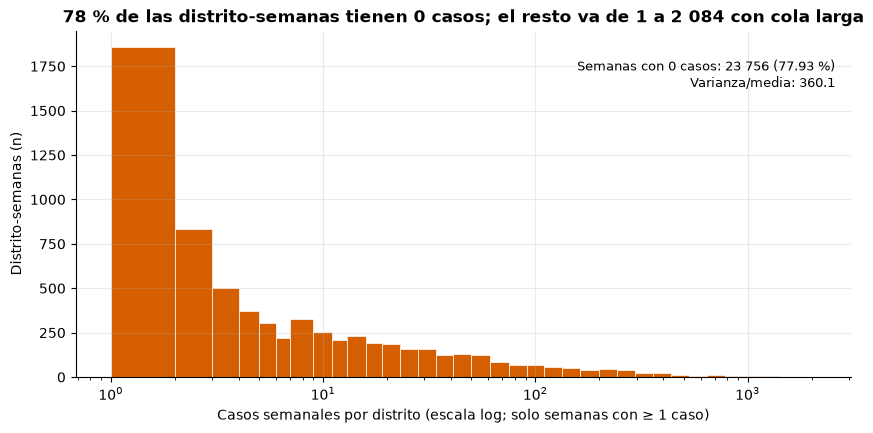

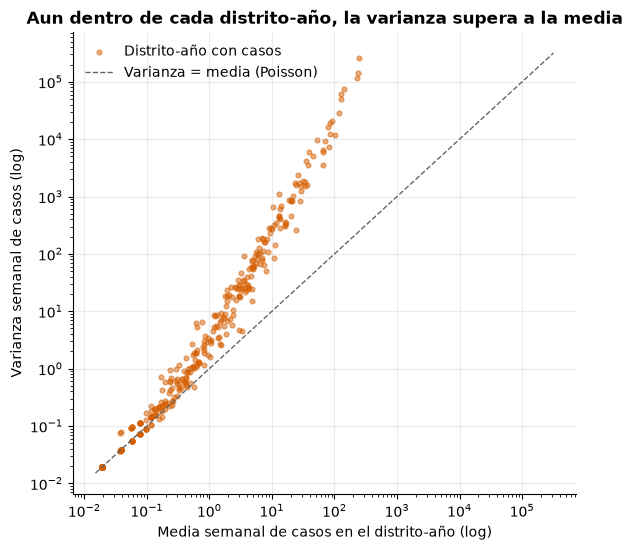

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
positivos = casos[casos > 0]
bins = np.unique(np.round(np.logspace(0, np.log10(positivos.max() + 1), 40)))
ax.hist(positivos, bins=bins, color=COLORES["casos"], edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.set(xlabel="Casos semanales por distrito (escala log; solo semanas con ≥ 1 caso)",
       ylabel="Distrito-semanas (n)",
       title=f"{M['pct_ceros']:.0f} % de las distrito-semanas tienen 0 casos; el resto va de 1 a {miles(M['maximo'])} con cola larga")
ax.text(0.98, 0.92, f"Semanas con 0 casos: {miles(int((casos == 0).sum()))} ({M['pct_ceros']} %)\nVarianza/media: {M['varianza_sobre_media']}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9)
guardar_figura(fig, FASE, "01_distribucion_casos")
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(da["mean"], da["var"], s=12, color=COLORES["casos"], alpha=0.5, label="Distrito-año con casos")
lim = [da["mean"].min() * 0.8, da["var"].max() * 1.2]
ax.plot(lim, lim, color=COLORES["referencia"], ls="--", lw=1, label="Varianza = media (Poisson)")
ax.set(xscale="log", yscale="log", xlabel="Media semanal de casos en el distrito-año (log)",
       ylabel="Varianza semanal de casos (log)",
       title="Aun dentro de cada distrito-año, la varianza supera a la media")
ax.legend(loc="upper left")
guardar_figura(fig, FASE, "02_sobredispersion_distrito_anio")
plt.show()

**Observación.** El objetivo tiene inflación de ceros y una cola muy larga. La sobredispersión no es solo efecto de mezclar distritos y años: se mantiene **dentro** de la mayoría de los distrito-años (figura 02). El reparto por año es muy desigual: pocos años concentran casi todos los casos (tabla).
**Cautela.** Dentro de un distrito-año la media cambia semana a semana (estacionalidad), así que var > media también aparecería con un Poisson de media variable. La figura 02 muestra heterogeneidad dentro del año, no necesariamente sobredispersión **condicional** a un modelo. Eso solo se puede evaluar con los residuos de un modelo que tenga estacionalidad (fase de modelado).
**Implicación.**
- **Hipótesis:** un Poisson simple subestimaría la varianza. Los candidatos naturales son una binomial negativa, un modelo con ceros inflados o un objetivo transformado (`log1p`), o bien pasar a una clasificación binaria de brote.
- Las métricas de error sobre conteos crudos estarán dominadas por unas pocas semanas extremas. Esto se decide en modelado; aquí solo se deja dimensionado.

## 2. Conteo vs tasa por 100 000 hab.

**Qué quiero saber:** si expresar el objetivo como tasa cambia qué distritos parecen "más afectados", y cuánto pesa la duda sobre la población de 2017.
Incidencia acumulada = casos del periodo / población media del periodo × 100 000.

In [4]:
tot = df.groupby("ubigeo").agg(casos=(OBJETIVO, "sum"), pob=("poblacion", "mean"))
tot["incidencia"] = tasa_100k(tot["casos"], tot["pob"])
tot = tot.join(nombre)
tot["rank_casos"] = tot["casos"].rank(ascending=False, method="min")
tot["rank_tasa"] = tot["incidencia"].rank(ascending=False, method="min")
rho = spearmanr(tot["casos"], tot["incidencia"]).statistic
top_c, top_t = set(tot.nlargest(10, "casos").index), set(tot.nlargest(10, "incidencia").index)
M.update({
    "spearman_casos_vs_incidencia_distritos": round(float(rho), 3),
    "top10_coinciden_casos_y_tasa": len(top_c & top_t),
    "top10_por_tasa": {tot.loc[u, "distrito"]: [round(float(tot.loc[u, "incidencia"]), 0), int(tot.loc[u, "rank_casos"])]
                       for u in tot.nlargest(10, "incidencia").index},
    "top10_por_casos": {tot.loc[u, "distrito"]: [int(tot.loc[u, "casos"]), int(tot.loc[u, "rank_tasa"])]
                        for u in tot.nlargest(10, "casos").index},
})
print(f"Spearman casos vs incidencia entre distritos: {M['spearman_casos_vs_incidencia_distritos']}. "
      f"Del top 10 por casos, {M['top10_coinciden_casos_y_tasa']} siguen en el top 10 por tasa.")
print("Top 10 por tasa [incidencia acumulada, puesto por casos]:", M["top10_por_tasa"])

# Sensibilidad de 2017 a la población (fase 1, hallazgo 4)
anual = df.groupby("anio").agg(casos=(OBJETIVO, "sum"), pob=("poblacion", lambda s: s.groupby(df.loc[s.index, "ubigeo"]).first().sum()))
anual["tasa"] = tasa_100k(anual["casos"], anual["pob"])
tasa_2017_con_pob_2018 = float(tasa_100k(anual.loc[2017, "casos"], anual.loc[2018, "pob"]))
M["incidencia_regional_anual"] = {int(a): round(float(v), 1) for a, v in anual["tasa"].items()}
M["incidencia_2017_con_pob_2018"] = round(tasa_2017_con_pob_2018, 1)
M["razon_2023_sobre_2017_pob_propia"] = round(float(anual.loc[2023, "tasa"] / anual.loc[2017, "tasa"]), 2)
M["razon_2023_sobre_2017_pob_2018"] = round(float(anual.loc[2023, "tasa"] / tasa_2017_con_pob_2018), 2)
print("Incidencia regional anual por 100 000 hab.:", M["incidencia_regional_anual"])
print(f"2017 con la población de 2018: {M['incidencia_2017_con_pob_2018']}. Razón 2023/2017: "
      f"{M['razon_2023_sobre_2017_pob_propia']} (población propia) vs {M['razon_2023_sobre_2017_pob_2018']} (población 2018).")

Spearman casos vs incidencia entre distritos: 0.831. Del top 10 por casos, 3 siguen en el top 10 por tasa.
Top 10 por tasa [incidencia acumulada, puesto por casos]: {'San Juan de Bigote': [19110.0, 21], 'La Huaca': [17020.0, 15], 'Salitral (Morropón)': [16820.0, 18], 'Piura': [16323.0, 1], 'Tamarindo': [13740.0, 30], 'Bellavista de la Union': [13561.0, 31], 'Castilla': [12581.0, 2], 'Salitral (Sullana)': [12458.0, 26], 'Ignacio Escudero': [12373.0, 14], 'Chulucanas': [11792.0, 6]}
Incidencia regional anual por 100 000 hab.: {2017: 2384.5, 2018: 26.1, 2019: 3.4, 2020: 6.0, 2021: 193.6, 2022: 571.2, 2023: 3688.6, 2024: 1484.1, 2025: 50.7}
2017 con la población de 2018: 2198.9. Razón 2023/2017: 1.55 (población propia) vs 1.68 (población 2018).


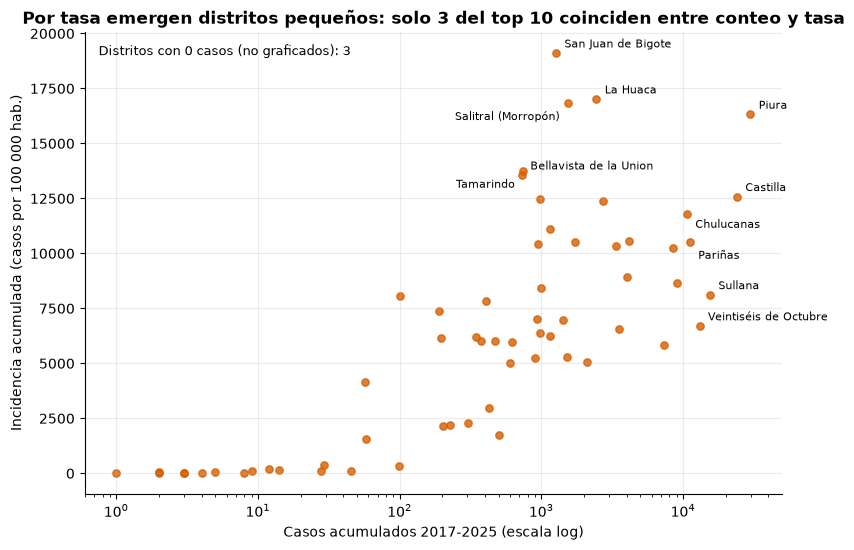

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
con = tot[tot["casos"] > 0]
ax.scatter(con["casos"], con["incidencia"], s=28, color=COLORES["casos"], alpha=0.8)
etiquetar = set(tot.nlargest(6, "casos").index) | set(tot.nlargest(6, "incidencia").index)
# Posición de etiquetas que chocan con su vecino: (desplazamiento x, desplazamiento y, alineación)
posicion = {"Tamarindo": (-6, -12, "right"), "Salitral (Morropón)": (-6, -12, "right"),
            "Chulucanas": (6, -10, "left"), "Pariñas": (6, -12, "left")}
for u in etiquetar:
    dx, dy, ha = posicion.get(tot.loc[u, "distrito"], (6, 4, "left"))
    ax.annotate(tot.loc[u, "distrito"], (tot.loc[u, "casos"], tot.loc[u, "incidencia"]),
                xytext=(dx, dy), ha=ha, textcoords="offset points", fontsize=8)
ax.set(xscale="log", xlabel="Casos acumulados 2017-2025 (escala log)",
       ylabel="Incidencia acumulada (casos por 100 000 hab.)",
       title=f"Por tasa emergen distritos pequeños: solo {M['top10_coinciden_casos_y_tasa']} del top 10 coinciden entre conteo y tasa")
ax.text(0.02, 0.95, f"Distritos con 0 casos (no graficados): {int((tot['casos'] == 0).sum())}", transform=ax.transAxes, fontsize=9)
guardar_figura(fig, FASE, "03_conteo_vs_tasa")
plt.show()

**Observación.** El orden de los distritos por conteo y por tasa está correlacionado, pero el "top" cambia bastante: por tasa aparecen distritos medianos y pequeños que por conteo quedan relegados. Además, la comparación entre 2017 y 2023 **depende** de qué población se use para 2017 (ver razones arriba).
**Implicación.**
- Con conteos, el modelo aprenderá sobre todo de las ciudades grandes (Piura, Castilla, Sullana). Con tasas, pesan más los distritos pequeños, cuyas tasas son más ruidosas.
- Opción intermedia: modelar conteos con la población como exposición (offset). Así el modelo compara riesgos sin que la ciudad grande domine y sin inflar el ruido de los distritos chicos. Recomendación, no decisión.
- Cualquier definición de brote basada en tasa hereda la duda sobre la población de 2017.

## 3. Concentración: ¿cuántos distritos "hacen" la epidemia?

**Qué quiero saber:** cuántos distritos concentran la mitad y el 80 % de los casos, cuántos están siempre en cero y cuántos casi nunca tienen casos.

5 distritos suman el 50 % de los casos y 12 el 80 %. Siempre en cero: ['Lagunas', 'Montero', 'Sicchez']. Distritos con casos en < 5 % de sus semanas (incluye a los siempre en cero): 15. Con casos en > 50 % de sus semanas: ['Castilla', 'Catacaos', 'Chulucanas', 'Piura', 'Sullana', 'Tambo Grande', 'Veintiséis de Octubre'].
% de casos por provincia: {'Piura': 52.4, 'Sullana': 17.1, 'Morropón': 9.7, 'Talara': 8.4, 'Paita': 8.0, 'Sechura': 3.7, 'Ayabaca': 0.5, 'Huancabamba': 0.2}
Mayor incidencia acumulada en Ayabaca/Huancabamba: {'Suyo': 4995.0, 'Paimas': 2177.0, 'San Miguel de el Faique': 2153.0} | mediana en las otras 6 provincias: 7365.0


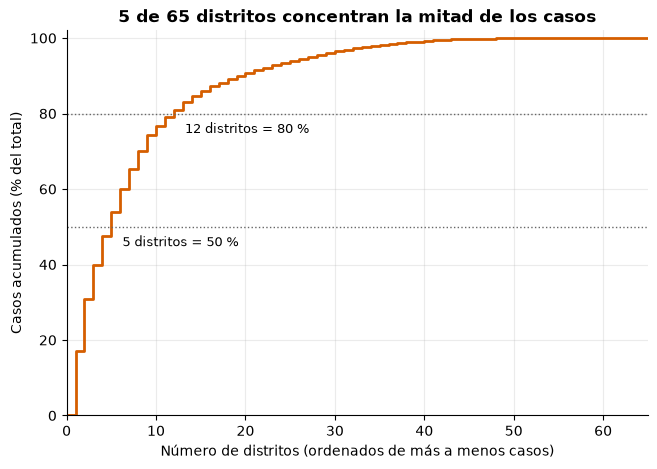

In [6]:
M["distritos_para_50pct_casos"] = unidades_para_fraccion(tot["casos"], 0.5)
M["distritos_para_80pct_casos"] = unidades_para_fraccion(tot["casos"], 0.8)
M["distritos_siempre_cero"] = sorted(tot.loc[tot["casos"] == 0, "distrito"])
semanas_con_casos = df.groupby("ubigeo")[OBJETIVO].apply(lambda s: (s > 0).mean() * 100)
M["distritos_menos_5pct_semanas_con_casos"] = int((semanas_con_casos < 5).sum())
M["distritos_mas_50pct_semanas_con_casos"] = sorted(nombre.loc[semanas_con_casos[semanas_con_casos > 50].index, "distrito"])
M["pct_casos_provincia"] = {p: round(float(v), 1) for p, v in
                            (df.groupby("provincia")[OBJETIVO].sum() / casos.sum() * 100).sort_values(ascending=False).items()}
M["pct_casos_sierra_ayabaca_huancabamba"] = round(M["pct_casos_provincia"]["Ayabaca"] + M["pct_casos_provincia"]["Huancabamba"], 1)
sierra = tot[tot["provincia"].isin(["Ayabaca", "Huancabamba"])].sort_values("incidencia", ascending=False)
M["incidencia_acumulada_max_ayabaca_huancabamba"] = {sierra["distrito"].iloc[i]: round(float(sierra["incidencia"].iloc[i]), 0) for i in range(3)}
M["mediana_incidencia_acumulada_resto_provincias"] = round(float(tot.loc[~tot.index.isin(sierra.index), "incidencia"].median()), 0)
print(f"{M['distritos_para_50pct_casos']} distritos suman el 50 % de los casos y {M['distritos_para_80pct_casos']} el 80 %. "
      f"Siempre en cero: {M['distritos_siempre_cero']}. Distritos con casos en < 5 % de sus semanas (incluye a los siempre en cero): {M['distritos_menos_5pct_semanas_con_casos']}. "
      f"Con casos en > 50 % de sus semanas: {M['distritos_mas_50pct_semanas_con_casos']}.")
print("% de casos por provincia:", M["pct_casos_provincia"])
print("Mayor incidencia acumulada en Ayabaca/Huancabamba:", M["incidencia_acumulada_max_ayabaca_huancabamba"],
      "| mediana en las otras 6 provincias:", M["mediana_incidencia_acumulada_resto_provincias"])

curva = curva_concentracion(tot["casos"])
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(np.r_[0, np.arange(1, len(curva) + 1)], np.r_[0, curva["prop_acumulada"]] * 100, color=COLORES["casos"], lw=2,
        drawstyle="steps-post")
for frac, n in [(50, M["distritos_para_50pct_casos"]), (80, M["distritos_para_80pct_casos"])]:
    ax.axhline(frac, color=COLORES["referencia"], ls=":", lw=1)
    ax.annotate(f"{n} distritos = {frac} %", (n, frac), xytext=(8, -14), textcoords="offset points", fontsize=9)
ax.set(xlabel="Número de distritos (ordenados de más a menos casos)", ylabel="Casos acumulados (% del total)",
       title=f"{M['distritos_para_50pct_casos']} de 65 distritos concentran la mitad de los casos", xlim=(0, 65), ylim=(0, 102))
guardar_figura(fig, FASE, "04_concentracion_distritos")
plt.show()

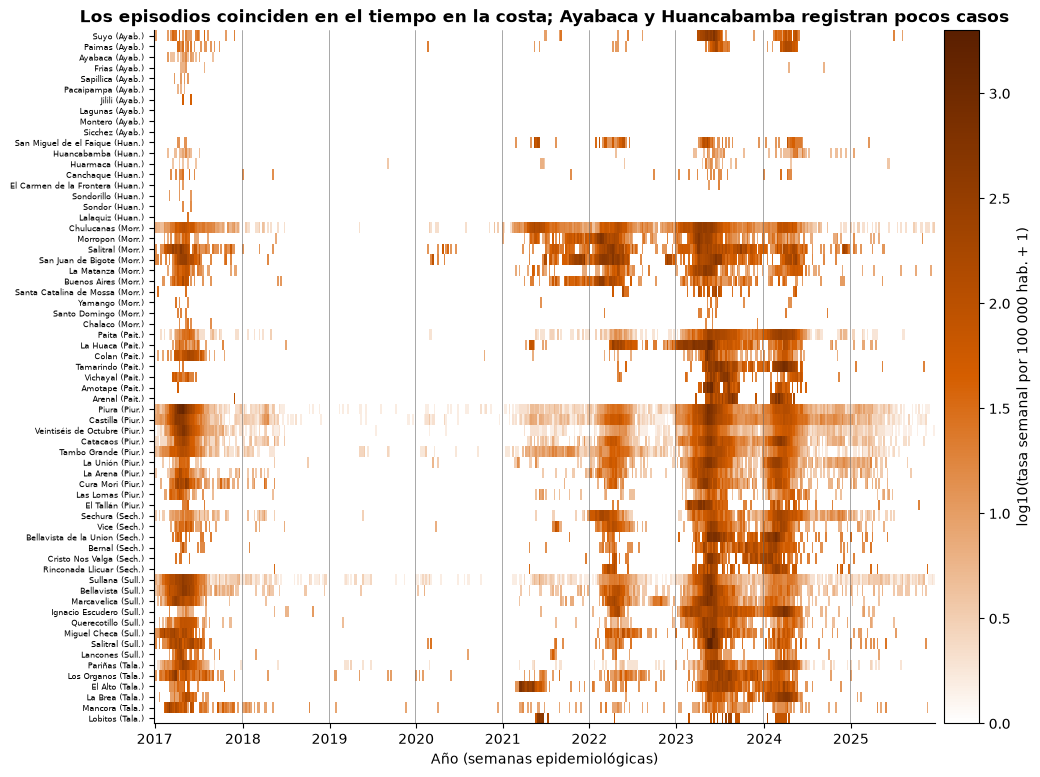

In [7]:
# Mapa de calor distrito x semana: dónde y cuándo ocurren los episodios
orden = tot.sort_values(["provincia", "casos"], ascending=[True, False]).index
matriz = pd.DataFrame({"u": df["ubigeo"], "f": df["semana_inicio"], "t": np.log10(tasa + 1)}).pivot(index="u", columns="f", values="t").loc[orden]
fig, ax = plt.subplots(figsize=(12, 9))
cmap = LinearSegmentedColormap.from_list("casos", ["#ffffff", COLORES["casos"], "#5a1f00"])
im = ax.imshow(matriz.values, aspect="auto", cmap=cmap, interpolation="nearest")
ax.set_yticks(range(len(orden)), [f"{tot.loc[u, 'distrito'].split(' (')[0]} ({tot.loc[u, 'provincia'][:4]}.)" for u in orden], fontsize=6)
inicio_anio = [i for i, f in enumerate(matriz.columns) if i == 0 or f.year != matriz.columns[i - 1].year]
ax.set_xticks(inicio_anio, [matriz.columns[i].year for i in inicio_anio])
for i in inicio_anio[1:]:
    ax.axvline(i - 0.5, color=COLORES["referencia"], lw=0.4)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.01)
cb.set_label("log10(tasa semanal por 100 000 hab. + 1)")
ax.set(xlabel="Año (semanas epidemiológicas)", title="Los episodios coinciden en el tiempo en la costa; Ayabaca y Huancabamba registran pocos casos")
guardar_figura(fig, FASE, "05_mapa_calor_distrito_semana")
plt.show()

**Observación.** Pocos distritos concentran la mayoría de los casos. Ayabaca y Huancabamba, tomadas como "sierra" por provincia (el dataset no trae altitud), aportan una fracción mínima **del conteo**. En tasa no son despreciables: algunos de sus distritos (Suyo en primer lugar) tienen incidencias acumuladas del mismo orden de magnitud que la mediana de las otras provincias, aunque menores (cifras arriba). El mapa de calor muestra que los años epidémicos afectan a muchos distritos de costa a la vez.
**Implicación.**
- Hay un grupo de distritos "silenciosos" (casi siempre en cero) donde el modelo solo aprenderá a predecir cero. Conviene decidir si se modelan aparte, se excluyen o se mantienen con un modelo global (fase 4 lo examina espacialmente).
- La aparente sincronía entre distritos se cuantifica en la fase 4. **Hipótesis:** hay un factor regional común.

## 4. Episodios: ¿cuántos brotes hay realmente?

**Qué quiero saber:** a nivel regional, en qué semana epidemiológica empieza y culmina cada temporada, con qué magnitud, y cuántas temporadas grandes hay.
Descripción operativa (no es la definición de brote): pico = semana con más casos regionales del año; inicio y fin = primera y última semana del año en que los casos regionales superan el 10 % de ese pico.

In [8]:
reg = df.groupby(["anio", "semana"])[OBJETIVO].sum().reset_index()
filas = []
for anio, g in reg.groupby("anio"):
    pico = g.loc[g[OBJETIVO].idxmax()]
    sobre = g[g[OBJETIVO] >= 0.1 * pico[OBJETIVO]]
    filas.append({"anio": anio, "semana_pico": int(pico["semana"]), "casos_pico": int(pico[OBJETIVO]),
                  "semana_inicio_10pct": int(sobre["semana"].min()), "semana_fin_10pct": int(sobre["semana"].max()),
                  "casos_anio": int(g[OBJETIVO].sum())})
temporadas = pd.DataFrame(filas).set_index("anio")
M["temporadas"] = {int(a): {k: int(v) for k, v in f.items()} for a, f in temporadas.iterrows()}
grandes = temporadas[temporadas["casos_anio"] >= 0.1 * temporadas["casos_anio"].sum()]
M["anios_con_10pct_o_mas_de_los_casos"] = [int(a) for a in grandes.index]
M["pct_casos_2017_2023_2024"] = round(float(temporadas.loc[[2017, 2023, 2024], "casos_anio"].sum() / temporadas["casos_anio"].sum() * 100), 1)
M["pct_casos_2017_2023"] = round(float(temporadas.loc[[2017, 2023], "casos_anio"].sum() / temporadas["casos_anio"].sum() * 100), 1)
M["semana_pico_rango_anios_grandes"] = [int(grandes["semana_pico"].min()), int(grandes["semana_pico"].max())]
print(f"Años con ≥ 10 % de los casos del periodo: {M['anios_con_10pct_o_mas_de_los_casos']} "
      f"(2017+2023 = {M['pct_casos_2017_2023']} %; 2017+2023+2024 = {M['pct_casos_2017_2023_2024']} %). "
      f"Semana del pico en esos años: {M['semana_pico_rango_anios_grandes']}.")
temporadas

Años con ≥ 10 % de los casos del periodo: [2017, 2023, 2024] (2017+2023 = 71.1 %; 2017+2023+2024 = 89.6 %). Semana del pico en esos años: [14, 20].


,semana_pico,casos_pico,semana_inicio_10pct,semana_fin_10pct,casos_anio
anio,,,,,
2017,18,5645,10,26,44275
2018,15,56,1,42,525
2019,22,8,5,52,70
2020,10,14,2,51,125
2021,20,243,11,52,4072
2022,16,830,1,27,12151
2023,20,8151,12,33,79304
2024,14,2555,1,25,32246
2025,4,58,1,47,1114


**Observación.** Hay pocas temporadas grandes, y 2024 también es una temporada importante, no solo 2017 y 2023. En 2022 y 2024 los casos ya superan el 10 % del pico desde la semana 1, lo que sugiere que esas temporadas empiezan el año anterior y cruzan el cambio de año. En 2025 el máximo regional cae temprano y es bajo: no hay una temporada visible (tabla). Los picos regionales de esas temporadas caen en la primera mitad del año, y varios años se extienden por muchas semanas sobre el 10 % del pico (tabla).
**Implicación.**
- En la práctica, el número efectivo de "brotes" independientes para aprender y validar es de apenas 3 temporadas grandes. Cualquier validación "dejando un año afuera" tendrá folds muy distintos entre sí.
- La fase 3 debe revisar si la temporada cruza el cambio de año, por ejemplo 2023 → 2024, porque eso afecta cómo se parten los folds.

### 4b. Contexto fuera del panel: el Excel silver trae años previos a 2017

**Qué quiero saber:** si la historia anterior a 2017 (presente en `data/silver/epi_piura_semanal.csv`, que se **lee** aquí sin modificarlo) tiene más temporadas epidémicas que podrían servir al modelo, y qué cobertura de distritos tiene.

Historia en el Excel: [2000, 2016], 54 de 65 distritos con algún caso. Años con > 5 000 casos: [2001, 2010, 2015, 2016].
Distritos del panel sin ningún caso antes de 2017: ['Amotape', 'Chalaco', 'El Carmen de la Frontera', 'Lagunas', 'Lalaquiz', 'Montero', 'Pacaipampa', 'Sapillica', 'Sicchez', 'Sondor', 'Sondorillo']


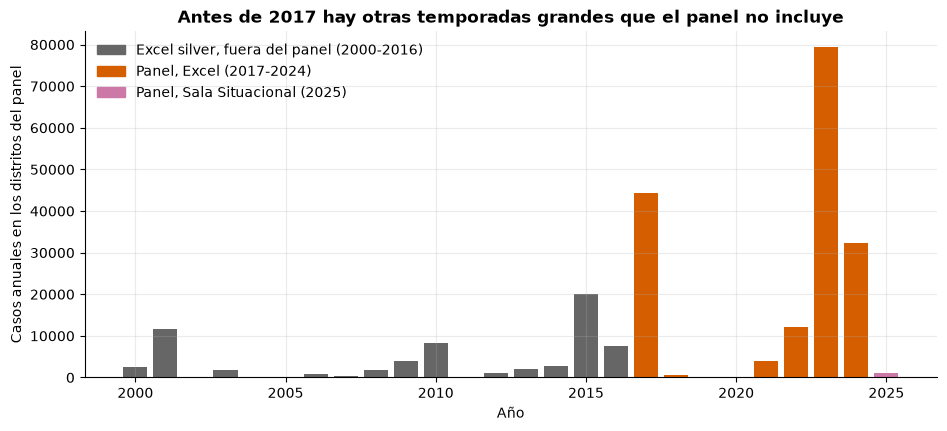

In [9]:
excel = pd.read_csv(SILVER / "epi_piura_semanal.csv", dtype={"ubigeo": "string"})
hist = excel[excel["ubigeo"].isin(df["ubigeo"].unique()) & (excel["anio"] < 2017)]
casos_hist = hist.groupby("anio")[OBJETIVO].sum()
distritos_hist = hist.groupby("anio")["ubigeo"].nunique()
M["excel_historia_anios"] = [int(casos_hist.index.min()), int(casos_hist.index.max())]
M["excel_historia_casos_por_anio"] = {int(a): int(v) for a, v in casos_hist.items()}
M["excel_historia_distritos_distintos"] = int(hist["ubigeo"].nunique())
M["excel_historia_distritos_ausentes"] = sorted(nombre.loc[sorted(set(df["ubigeo"]) - set(hist["ubigeo"])), "distrito"])
M["excel_historia_anios_mas_de_5000_casos"] = [int(a) for a in casos_hist[casos_hist > 5000].index]
print(f"Historia en el Excel: {M['excel_historia_anios']}, {M['excel_historia_distritos_distintos']} de 65 distritos con algún caso. "
      f"Años con > 5 000 casos: {M['excel_historia_anios_mas_de_5000_casos']}.")
print("Distritos del panel sin ningún caso antes de 2017:", M["excel_historia_distritos_ausentes"])

serie = pd.concat([casos_hist, df.groupby("anio")[OBJETIVO].sum()])
fig, ax = plt.subplots(figsize=(11, 4.5))
colores = [COLORES["referencia"] if a < 2017 else (COLORES["resalte"] if a == 2025 else COLORES["casos"]) for a in serie.index]
ax.bar(serie.index, serie.values, color=colores, width=0.8)
ax.legend(handles=[Patch(color=COLORES["referencia"], label="Excel silver, fuera del panel (2000-2016)"),
                   Patch(color=COLORES["casos"], label="Panel, Excel (2017-2024)"),
                   Patch(color=COLORES["resalte"], label="Panel, Sala Situacional (2025)")], loc="upper left")
ax.set(xlabel="Año", ylabel="Casos anuales en los distritos del panel",
       title="Antes de 2017 hay otras temporadas grandes que el panel no incluye")
guardar_figura(fig, FASE, "06_casos_anuales_con_historia")
plt.show()

**Observación.** El Excel silver contiene años anteriores al panel con temporadas de miles de casos (lista arriba). Algunos distritos del panel no tienen ningún registro antes de 2017.
**Hipótesis.** Algunas ausencias pueden deberse a distritos creados después (cambios de ubigeo) o a subregistro; no se puede verificar con el repo.
**Implicación.**
- Extender el panel hacia atrás (Open-Meteo ofrece reanálisis histórico) sumaría temporadas epidémicas independientes, que es justamente lo que más falta para validar y generalizar.
- Faltaría sociodemografía para esos años: habría que extrapolarla, un supuesto fuerte.
- Es una decisión de alcance para Rosa y el asesor; aquí solo se cuantifica.

## 5. Definiciones candidatas de brote

No se elige ninguna. Se cuantifican cuatro familias con parámetros **ilustrativos** (no calibrados ni tomados de la literatura), para ver cuántos positivos, episodios y desbalance produce cada una y de qué años y distritos salen:

| | Definición | Parámetro ilustrativo | ¿Usa información futura? |
|---|---|---|---|
| D1 | Tasa semanal ≥ umbral fijo | 10 por 100 000 hab. (y barrido 1-100) | No |
| D2 | Casos > percentil del propio distrito (y ≥ 1) | p90 de toda la serie | **Sí**, si el percentil se calcula con todo el periodo |
| D3 | Canal endémico: casos > Q3 de la misma semana en los 5 años previos (y ≥ 1) | 5 años (usa el Excel 2012-2016 para 2017-2021) | No |
| D4 | Aumento sostenido: ≥ 2× la media de las 8 semanas previas, ≥ 5 casos, durante ≥ 3 semanas | 2×, 8, 5, 3 | No |

Referencia: "cualquier caso" (casos ≥ 1).

In [10]:
defs = {
    "D1 tasa ≥ 10/100k": brote_umbral_tasa(df, 10),
    "D2 > p90 del distrito": brote_percentil_distrito(df, 0.9),
    "D3 canal endémico": brote_canal_endemico(df, hist, anios_previos=5),
    "D4 aumento sostenido": brote_aumento_sostenido(df, factor=2, ventana=8, k=3, minimo=5),
    "Referencia: ≥ 1 caso": casos >= 1,
}
res = {k: resumen_definicion(df, v) for k, v in defs.items()}
res_sin_2025 = {k: resumen_definicion(df[sin_2025], v[sin_2025]) for k, v in defs.items()}
M["definiciones"] = res
M["definiciones_pct_positivos_sin_2025"] = {k: v["pct_filas_positivas"] for k, v in res_sin_2025.items()}

# Episodios de 1 semana (fragmentación) por definición
for k, v in defs.items():
    ep = rachas(df.assign(_m=v.to_numpy()), "_m")
    M["definiciones"][k]["pct_episodios_de_1_semana"] = round(float((ep["duracion"] == 1).mean() * 100), 1)

# D3: ¿cuántos positivos salen de distrito-semanas cuyo canal histórico es 0 (cualquier caso = brote)?
q3 = umbral_canal_endemico(df, hist, anios_previos=5)
q3_cero = q3 == 0
M["D3_pct_positivos_con_canal_en_cero"] = round(float((defs["D3 canal endémico"] & q3_cero).sum() / defs["D3 canal endémico"].sum() * 100), 1)
M["D3_pct_distrito_semanas_con_canal_en_cero"] = round(float(q3_cero.mean() * 100), 1)
M["D3_pct_canal_en_cero_por_anio"] = {int(a): round(float(v * 100), 1) for a, v in q3_cero.groupby(df["anio"]).mean().items()}
print("D3, % de distrito-semanas con canal en 0 por año:", M["D3_pct_canal_en_cero_por_anio"])

# D4: ¿los episodios preceden al pico? Semanas desde el inicio del episodio hasta el máximo del distrito
# en las 26 semanas siguientes (incluida la de inicio), y si ese máximo cae después de que termina el episodio.
ep4 = rachas(df.assign(_m=defs["D4 aumento sostenido"].to_numpy()), "_m")
serie = df.set_index(["ubigeo", "semana_inicio"])[OBJETIVO]
adelantos, despues = [], []
for e in ep4.itertuples():
    ventana = serie.loc[e.ubigeo].loc[e.inicio:e.inicio + pd.Timedelta(weeks=25)]
    f_max = ventana.idxmax()
    adelantos.append((f_max - e.inicio).days // 7)
    despues.append(f_max > e.fin)
M["D4_semanas_inicio_a_pico_mediana"] = float(np.median(adelantos))
M["D4_semanas_inicio_a_pico_p25_p75"] = [float(np.percentile(adelantos, 25)), float(np.percentile(adelantos, 75))]
M["D4_pct_episodios_pico_despues_del_episodio"] = round(float(np.mean(despues) * 100), 1)
print(f"D4: del inicio del episodio al máximo de las 26 semanas siguientes hay una mediana de {M['D4_semanas_inicio_a_pico_mediana']} semanas "
      f"(p25-p75 {M['D4_semanas_inicio_a_pico_p25_p75']}); en el {M['D4_pct_episodios_pico_despues_del_episodio']} % el máximo llega después de que el episodio termina.")

tabla = pd.DataFrame(res).T[["pct_filas_positivas", "razon_negativos_por_positivo", "episodios", "duracion_mediana_semanas",
                             "pct_episodios_de_1_semana", "distritos_con_algun_positivo", "pct_positivos_en_2017_2023", "pct_casos_cubiertos"]]
tabla["pct_filas_positivas_sin_2025"] = pd.Series(M["definiciones_pct_positivos_sin_2025"])
print(f"D3: {M['D3_pct_distrito_semanas_con_canal_en_cero']} % de las distrito-semanas tienen canal histórico en 0 (Q3 = 0); "
      f"de ahí sale el {M['D3_pct_positivos_con_canal_en_cero']} % de los positivos de D3.")
tabla

D3, % de distrito-semanas con canal en 0 por año: {2017: 79.6, 2018: 70.6, 2019: 70.3, 2020: 71.1, 2021: 78.1, 2022: 84.1, 2023: 84.9, 2024: 68.7, 2025: 57.8}
D4: del inicio del episodio al máximo de las 26 semanas siguientes hay una mediana de 7.0 semanas (p25-p75 [3.0, 10.0]); en el 51.6 % el máximo llega después de que el episodio termina.
D3: 73.9 % de las distrito-semanas tienen canal histórico en 0 (Q3 = 0); de ahí sale el 65.2 % de los positivos de D3.


,pct_filas_positivas,razon_negativos_por_positivo,episodios,duracion_mediana_semanas,pct_episodios_de_1_semana,distritos_con_algun_positivo,pct_positivos_en_2017_2023,pct_casos_cubiertos,pct_filas_positivas_sin_2025
D1 tasa ≥ 10/100k,13.37,6.5,805,1.0,55.8,59,55.3,95.6,14.88
D2 > p90 del distrito,6.96,13.4,516,1.0,54.1,62,62.6,82.0,7.81
D3 canal endémico,17.12,4.8,1176,1.0,58.6,62,53.9,96.9,19.05
D4 aumento sostenido,2.48,39.4,153,4.0,0.0,45,58.1,39.2,2.79
Referencia: ≥ 1 caso,22.07,3.5,1424,1.0,58.9,62,44.8,100.0,23.24


In [11]:
barrido = pd.DataFrame({u: resumen_definicion(df, brote_umbral_tasa(df, u)) for u in [1, 5, 10, 20, 50, 100]}).T
M["D1_barrido_umbral"] = {int(u): {k: fila[k] for k in ["pct_filas_positivas", "episodios", "distritos_con_algun_positivo",
                                                       "pct_positivos_en_2017_2023", "pct_casos_cubiertos"]}
                          for u, fila in barrido.iterrows()}
barrido[["pct_filas_positivas", "razon_negativos_por_positivo", "episodios", "distritos_con_algun_positivo",
         "pct_positivos_en_2017_2023", "pct_casos_cubiertos"]]

,pct_filas_positivas,razon_negativos_por_positivo,episodios,distritos_con_algun_positivo,pct_positivos_en_2017_2023,pct_casos_cubiertos
1,20.78,3.8,1377,62,47.2,99.8
5,16.51,5.1,1059,61,52.9,97.9
10,13.37,6.5,805,59,55.3,95.6
20,9.68,9.3,553,53,58.6,91.2
50,5.89,16.0,336,47,62.3,81.7
100,3.51,27.5,220,47,67.0,68.3


% de positivos en 2017, 2022, 2023 y 2024: {'D1 tasa ≥ 10/100k': 92.6, 'D2 > p90 del distrito': 96.3, 'D3 canal endémico': 90.7, 'D4 aumento sostenido': 93.4, 'Referencia: ≥ 1 caso': 79.7}


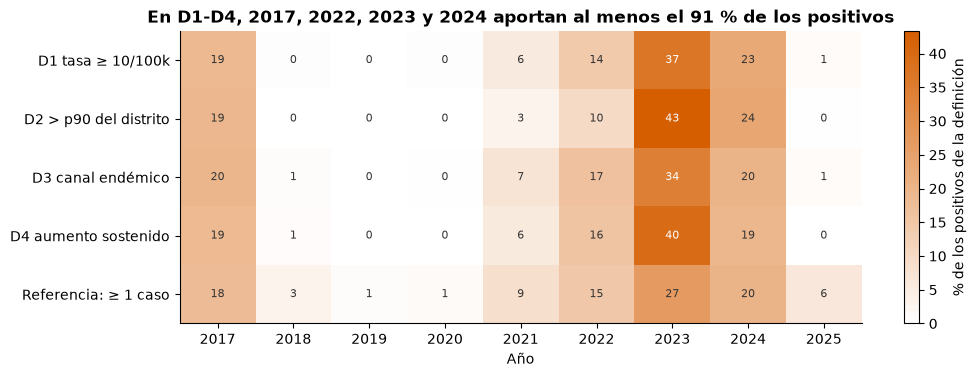

In [12]:
pos_anio = pd.DataFrame({k: v["positivos_por_anio"] for k, v in res.items()}).T
ANIOS_GRANDES = [2017, 2022, 2023, 2024]
M["pct_positivos_en_2017_2022_2023_2024"] = {k: round(float(fila[ANIOS_GRANDES].sum() / fila.sum() * 100), 1) for k, fila in pos_anio.iterrows()}
minimo_d = min(v for k, v in M["pct_positivos_en_2017_2022_2023_2024"].items() if k.startswith("D"))
print("% de positivos en 2017, 2022, 2023 y 2024:", M["pct_positivos_en_2017_2022_2023_2024"])
pct_anio = pos_anio.div(pos_anio.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(11, 3.8))
cmap = LinearSegmentedColormap.from_list("casos", ["#ffffff", COLORES["casos"]])
im = ax.imshow(pct_anio.values, aspect="auto", cmap=cmap, vmin=0)
ax.set_xticks(range(pct_anio.shape[1]), pct_anio.columns)
ax.set_yticks(range(pct_anio.shape[0]), pct_anio.index)
for i in range(pct_anio.shape[0]):
    for j in range(pct_anio.shape[1]):
        v = pct_anio.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if v > 30 else "#333333")
ax.grid(False)
fig.colorbar(im, ax=ax, label="% de los positivos de la definición")
ax.set(xlabel="Año", title=f"En D1-D4, 2017, 2022, 2023 y 2024 aportan al menos el {minimo_d:.0f} % de los positivos")
guardar_figura(fig, FASE, "07_definiciones_positivos_por_anio")
plt.show()

**Observación** (cifras en la tabla y el JSON).
- **D1** (umbral de tasa) es sensible al umbral: al subirlo se pierden distritos y años enteros. Con umbrales bajos se parece a "cualquier caso".
- **D2** exige ≥ 1 caso porque en muchos distritos el p90 es 0. Además usa el futuro, así que en el modelado habría que recalcularla solo con datos de entrenamiento.
- **D3** (canal endémico) no usa información futura, pero en la **mayoría** de las distrito-semanas el canal histórico es 0 (Q3 de los 5 años previos = 0; cifras arriba). Ahí un solo caso ya cuenta como brote, y la mayoría de sus positivos sale de esas semanas: en la práctica, D3 se parece mucho a "≥ 1 caso". Para que discrimine haría falta, por ejemplo, exigir un mínimo de casos, usar media + 2 desviaciones estándar o agrupar semanas vecinas para estimar el canal (alternativas no evaluadas aquí).
- **D4** (aumento sostenido) produce pocos positivos y cubre una fracción menor de los casos. No tiene episodios de 1 semana **por construcción** (exige ≥ 3 semanas). Sus episodios suelen empezar antes del máximo local, que llega unas semanas después, a veces cuando el episodio ya terminó (cifras arriba). Detecta la fase de subida, aunque no siempre anticipa el pico completo.
- En D1-D3 más de la mitad de los episodios dura una sola semana: la serie distrital es ruidosa.
- En todas, pocos años aportan casi todos los positivos. 2025 aporta muy pocos, sea por la fuente o por la epidemiología.

**Implicación.**
- El desbalance va de moderado (D1 con umbral bajo, D3) a severo (D2, D4). Habrá que usar métricas para clases desbalanceadas (PR-AUC, recall de brotes) y no la exactitud.
- La definición determina si el modelo predice **nivel** (D1-D3) o **arranque** (D4). Para anticipar 4 semanas, el arranque suele ser lo que se quiere avisar, pero es la clase más rara. Esto es una **hipótesis de diseño** para discutir con el asesor.
- Suavizar episodios (por ejemplo, unir rachas separadas por 1 semana) o exigir un mínimo de casos reduciría la fragmentación. Eso se decide en feature engineering.

In [13]:
ruta = guardar_metricas(FASE, M)
print("Métricas guardadas en", ruta.relative_to(ruta.parents[3]))

Métricas guardadas en docs\eda\metricas\fase2_variable_objetivo.json
